# Robust Optimization for Surgical Planning

The deterministic model is often too optimistic, while the stochastic model focuses on the "average" case. In a hospital environment, we often need a **guarantee of feasibility** even when things go wrong.

**Robust Optimization** addresses this by protecting the schedule against all uncertainty scenarios within a defined **"budget of uncertainty"** ($\Gamma$). This approach ensures that the schedule remains feasible even if a specific number of patients simultaneously experience their maximum potential delay.

## 1. Mathematical Foundation: The Dual Formulation

To protect against the worst-case scenario without testing millions of possibilities, we use the **Bertsimas & Sim** approach. We transform a complex "Max" problem (finding the worst delay) into a "Min" problem using **Strong Duality**.

### Sets and Parameters
* $\Gamma$ : The **Uncertainty Budget**. It represents the maximum number of patients whose durations can simultaneously reach their peak value ($t_{i,\text{fixed}} + t_{i,\text{sup}}$) on a given day.
* $q_{jk},\, r_{ik}$ : Dual variables used to linearize the worst-case protection function.

### Robust Capacity Constraint
For each specialty $j$ on day $k$, the capacity constraint in the worst case becomes:
$$\sum_{i \in I \mid s_i = j} t_{i,\text{fixed}}\, x_{ik} + \Gamma\, q_{jk} + \sum_{i \in I \mid s_i = j} r_{ik} - H\, y_{jk} \le \tau_{jk}$$

Subject to the **dual protection link**:
$$q_{jk} + r_{ik} \ge t_{i,\text{sup}}\, x_{ik} \quad \forall\, i,\; j = s_i,\; k$$

This guarantees that even if exactly $\Gamma$ patients reach their maximum duration simultaneously (worst case tolerated by the budget), the overtime $\tau_{jk}$ will not be exceeded.

In [1]:
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

# --- Gestion des dossiers de sortie ---
OUTPUT_DIR = "results_robust"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Dossier '{OUTPUT_DIR}' créé pour les résultats.")

Dossier 'results_robust' créé pour les résultats.


In [3]:
# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
FILENAME = "data/surgery_data.xlsx"
H_REGULAR     = 8.0   # Standard working hours per day
H_MAX_OVERTIME = 2.0  # Maximum overtime hours allowed
MAX_TOTAL_TIME = H_REGULAR + H_MAX_OVERTIME

# Range of Gamma values to evaluate (1 to 6 inclusive)
GAMMAS_TO_TEST = range(1, 7)

# Severity levels for the stress test:
# alpha_max = 0.8  => delays up to 80% of the predicted overtime ("low" stress test)
# alpha_max = 1.0  => delays up to 100% of the predicted overtime (nominal stress test)
# alpha_max = 1.2  => delays up to 120% of the predicted overtime (high stress test)
# alpha_max = 1.5  => delays up to 150% of the predicted overtime (extreme stress test)
ALPHAS_TO_TEST = [0.8, 1.0, 1.2, 1.5]

N_SCENARIOS = 100   # Number of scenarios per test set
N_TEST_SETS = 3     # Number of fixed test sets (for dispersion analysis)

# ==========================================
# 2. DATA LOADING
# ==========================================
try:
    df = pd.read_excel(FILENAME, sheet_name="Patients")
    df.columns = ['Patient_ID', 'Spec_ID', 'Specialty', 'Duration', 'Overtime']
    df_costs = pd.read_excel(FILENAME, sheet_name="Specialties")
    df['Specialty']      = df['Specialty'].str.strip().str.upper()
    df_costs['names']    = df_costs['names'].str.strip().str.upper()
except FileNotFoundError:
    print(f"ERROR: File '{FILENAME}' not found.")
    raise

patients    = [f"P{i}" for i in df['Patient_ID']]
specialties = df['Specialty'].unique().tolist()
days        = list(range(1, 8))
day_map     = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
               5: "Friday",  6: "Saturday", 7: "Sunday"}

# Index mapping: patient name -> column index in the scenario matrix
patient_map          = {name: i for i, name in enumerate(patients)}
base_fixed_costs     = {row['names']: row['fixed cost']              for _, row in df_costs.iterrows()}
base_overtime_costs  = {row['names']: row['overtime cost (per h)']   for _, row in df_costs.iterrows()}
t_fixe               = {f"P{row.Patient_ID}": row.Duration  for _, row in df.iterrows()}
t_sup                = {f"P{row.Patient_ID}": row.Overtime  for _, row in df.iterrows()}
patient_specialty    = {f"P{row.Patient_ID}": row.Specialty for _, row in df.iterrows()}

# Pre-computation of daily costs with weekend surcharges
C_jk       = {}
C_prime_jk = {}
for j in specialties:
    for k in days:
        multiplier = 1.0 if k <= 5 else (1.25 if k == 6 else 1.8)
        C_jk[(j, k)]       = base_fixed_costs[j]    * multiplier
        C_prime_jk[(j, k)] = base_overtime_costs[j] * multiplier

print(f"Data loaded: {len(patients)} patients | {len(specialties)} specialties | {len(days)} days")

Data loaded: 56 patients | 5 specialties | 7 days


## 2. Robust Solver

This function builds the robust ILP model for a specific value of $\Gamma$. It incorporates the dual variables $q_{jk}$ and $r_{ik}$ to protect the capacity constraints against the worst-case combination of delays.

> *This code uses Gurobi when available, and falls back to CBC (`PULP_CBC_CMD`) otherwise.*

In [4]:
def solve_robust_model(gamma_val):
    """Solve the robust surgical scheduling model for a given uncertainty budget Gamma."""
    model = pulp.LpProblem(f"Robust_Gamma_{gamma_val}", pulp.LpMinimize)

    x   = pulp.LpVariable.dicts("X",   (patients,    days), cat='Binary')
    y   = pulp.LpVariable.dicts("Y",   (specialties, days), cat='Binary')
    tau = pulp.LpVariable.dicts("Tau", (specialties, days), lowBound=0)
    q   = pulp.LpVariable.dicts("q",   (specialties, days), lowBound=0)
    r   = pulp.LpVariable.dicts("r",   (patients,    days), lowBound=0)

    # Objective: Minimize total cost (fixed room opening + robust overtime)
    model += pulp.lpSum(
        C_jk[(j, k)] * y[j][k] + C_prime_jk[(j, k)] * tau[j][k]
        for j in specialties for k in days
    )

    # --- Structural constraints ---
    # Each patient is scheduled exactly once
    for i in patients:
        model += pulp.lpSum(x[i][k] for k in days) == 1

    # At most one specialty per day
    for k in days:
        model += pulp.lpSum(y[j][k] for j in specialties) <= 1

    # A patient can only be scheduled on a day allocated to their specialty
    for i in patients:
        for k in days:
            model += x[i][k] <= y[patient_specialty[i]][k]

    # --- Robust constraints (Bertsimas & Sim dualisation) ---
    for j in specialties:
        p_in_j = [i for i in patients if patient_specialty[i] == j]
        for k in days:
            # Robust capacity: nominal times + worst-case Gamma-bounded overtime
            lhs = (
                pulp.lpSum(t_fixe[i] * x[i][k] for i in p_in_j)
                + gamma_val * q[j][k]
                + pulp.lpSum(r[i][k] for i in p_in_j)
            )
            model += lhs - H_REGULAR * y[j][k] <= tau[j][k]

            # Dual linking constraints
            for i in p_in_j:
                model += q[j][k] + r[i][k] >= t_sup[i] * x[i][k]

            # Legal overtime cap
            model += tau[j][k] <= H_MAX_OVERTIME * y[j][k]

    solver = pulp.GUROBI(msg=0) if pulp.GUROBI().available() else pulp.PULP_CBC_CMD(msg=0)
    model.solve(solver)
    return model.status, x, y

## 3. Pre-generating Fixed Scenario Matrices

This is the **critical methodological fix** compared to a naive implementation.

### Why fixed matrices?

A common mistake is to regenerate random scenarios inside the evaluation function. This means:
- Gamma=1 is tested against one random draw
- Gamma=2 is tested against a *different* random draw
- → The comparison is **not fair**: differences in reliability could come from random variation, not from Gamma!

The correct approach (from **ROBUSTE3scenar.py** / **ROBUSTE4.py**) is to:
1. **Pre-generate** fixed scenario matrices once, before any optimization.
2. **Reuse the same matrices** to evaluate every Gamma value.
3. Use **multiple test sets** (here: 3) to measure the **dispersion** of results and confirm that observed differences are real.

This ensures the comparison between Gamma values is controlled and reproducible.

In [5]:
# Pre-generate fixed test sets (done once, reused for all Gamma values)
# Shape: (N_SCENARIOS, n_patients) — each row is one scenario, each column one patient
np.random.seed(42)

# We create one collection of fixed matrices per alpha level
fixed_test_sets = {
    alpha_max: [
        np.random.uniform(0, alpha_max, size=(N_SCENARIOS, len(patients)))
        for _ in range(N_TEST_SETS)
    ]
    for alpha_max in ALPHAS_TO_TEST
}

print(f"Fixed scenario matrices generated (seed=42):")
for alpha_max, sets in fixed_test_sets.items():
    print(f"  alpha_max={alpha_max}: {len(sets)} sets × {sets[0].shape} (scenarios × patients)")

Fixed scenario matrices generated (seed=42):
  alpha_max=0.8: 3 sets × (100, 56) (scenarios × patients)
  alpha_max=1.0: 3 sets × (100, 56) (scenarios × patients)
  alpha_max=1.2: 3 sets × (100, 56) (scenarios × patients)
  alpha_max=1.5: 3 sets × (100, 56) (scenarios × patients)


## 4. Evaluation Function

This function evaluates a given planning `(x, y)` against a **pre-generated scenario matrix**. It returns both the reliability rate and the average realized cost.

Key design choices:
- The scenario matrix is passed as an argument (not regenerated inside), ensuring fair comparison.
- `patient_map[i]` maps a patient ID to its column index in the matrix.
- Overtime costs are computed based on *actual* realized time, not the model's worst-case estimate.

In [6]:
def evaluate_planning(x, y, scenario_matrix):
    """
    Evaluate a planning (x, y) against a pre-generated scenario matrix.

    Parameters
    ----------
    x, y            : PuLP decision variable dicts (solved)
    scenario_matrix : np.ndarray of shape (n_scenarios, n_patients)
                      Each entry is the alpha coefficient for patient i in scenario s.

    Returns
    -------
    reliability : float  — % of scenarios where total daily time <= MAX_TOTAL_TIME
    avg_cost    : float  — average total realized cost over all scenarios (€)
    """
    n_sims = scenario_matrix.shape[0]
    violations = 0
    total_costs = []

    # Fixed structural cost (room opening): does not depend on the scenario
    fixed_cost = sum(
        C_jk[(j, k)]
        for j in specialties for k in days
        if y[j][k].varValue is not None and y[j][k].varValue > 0.5
    )

    for s_idx in range(n_sims):
        alpha_row = scenario_matrix[s_idx]  # shape: (n_patients,)
        scenario_overtime_cost = 0.0
        is_feasible = True

        for k in days:
            # Identify the active specialty on this day
            active_j = next(
                (j for j in specialties
                 if y[j][k].varValue is not None and y[j][k].varValue > 0.5),
                None
            )
            if active_j is None:
                continue

            # Patients scheduled on this day
            p_on_day = [
                i for i in patients
                if x[i][k].varValue > 0.5 and patient_specialty[i] == active_j
            ]

            # Realized total operating time using the pre-generated alpha
            real_time = sum(
                t_fixe[i] + alpha_row[patient_map[i]] * t_sup[i]
                for i in p_on_day
            )

            if real_time > MAX_TOTAL_TIME:
                is_feasible = False

            actual_overtime = max(0.0, real_time - H_REGULAR)
            scenario_overtime_cost += actual_overtime * C_prime_jk[(active_j, k)]

        if not is_feasible:
            violations += 1
        total_costs.append(fixed_cost + scenario_overtime_cost)

    reliability = 100.0 * (1 - violations / n_sims)
    avg_cost    = float(np.mean(total_costs))
    return reliability, avg_cost

## 5. Phase 1 — Optimization: Solve Once per Gamma, Cache Results

We solve the robust ILP for each value of $\Gamma \in \{1, \ldots, 6\}$ and store the resulting planning. This avoids redundant computation: each planning is solved **once** and then evaluated against multiple alpha levels.

Note: if the model becomes infeasible for a given $\Gamma$, increasing $\Gamma$ further will not help (it only tightens the constraints), so we stop early.

In [7]:
print(">>> Phase 1: Solving robust model for each Gamma...")
print("(Note: uses Gurobi if available, otherwise CBC)\n")

solutions_cache = {}  # gamma -> (x_sol, y_sol)

for g in GAMMAS_TO_TEST:
    print(f"  Optimizing Gamma = {g} ...", end=" ", flush=True)
    status, x_sol, y_sol = solve_robust_model(g)

    if pulp.LpStatus[status] == 'Optimal':
        solutions_cache[g] = (x_sol, y_sol)
        print("OPTIMAL")
    else:
        print(f"INFEASIBLE (status: {pulp.LpStatus[status]}) — stopping.")
        break

print(f"\n{len(solutions_cache)} optimal plannings found for Gamma in {list(solutions_cache.keys())}")

>>> Phase 1: Solving robust model for each Gamma...
(Note: uses Gurobi if available, otherwise CBC)

  Optimizing Gamma = 1 ... Restricted license - for non-production use only - expires 2027-11-29
Restricted license - for non-production use only - expires 2027-11-29
OPTIMAL
  Optimizing Gamma = 2 ... Restricted license - for non-production use only - expires 2027-11-29
OPTIMAL
  Optimizing Gamma = 3 ... Restricted license - for non-production use only - expires 2027-11-29
OPTIMAL
  Optimizing Gamma = 4 ... Restricted license - for non-production use only - expires 2027-11-29
OPTIMAL
  Optimizing Gamma = 5 ... Restricted license - for non-production use only - expires 2027-11-29
OPTIMAL
  Optimizing Gamma = 6 ... Restricted license - for non-production use only - expires 2027-11-29
OPTIMAL

6 optimal plannings found for Gamma in [1, 2, 3, 4, 5, 6]


## 6. Phase 2 — Simulation: Evaluate Each Planning Against Fixed Scenarios

For each combination of (Gamma, alpha_max), we evaluate the cached planning against the **3 pre-generated test sets**. This gives:
- A **mean reliability** and **mean cost** across the 3 sets
- A **dispersion band** (min/max) that shows how stable the results are

The dispersion band is important: if it is narrow, the result is stable and trustworthy. If it is wide, we would need more scenarios.

### Why we test multiple alpha levels
- **alpha_max = 1.0**: "nominal" stress test — delays up to 100% of the predicted overtime
- **alpha_max = 1.5**: "extreme" stress test — delays up to 150% of the predicted overtime (as used in the original analysis for the extreme-case $\Gamma$ selection)

In [8]:
print(">>> Phase 2: Simulation on fixed scenario matrices...\n")

all_results = {}  # alpha_max -> list of dicts

for current_alpha in ALPHAS_TO_TEST:
    print(f"--- Severity level alpha_max = {current_alpha} ---")
    results_for_alpha = []

    for g, (x_sol, y_sol) in solutions_cache.items():
        batch_rel, batch_cost = [], []

        # Evaluate against each of the N_TEST_SETS fixed matrices
        for scenario_set in fixed_test_sets[current_alpha]:
            rel, cost = evaluate_planning(x_sol, y_sol, scenario_set)
            batch_rel.append(rel)
            batch_cost.append(cost)

        mean_rel  = float(np.mean(batch_rel))
        min_rel   = float(np.min(batch_rel))
        max_rel   = float(np.max(batch_rel))
        mean_cost = float(np.mean(batch_cost))

        results_for_alpha.append({
            "Gamma":      g,
            "Reliability_mean": mean_rel,
            "Reliability_min":  min_rel,
            "Reliability_max":  max_rel,
            "Avg_Cost":   mean_cost,
        })
        print(f"  Gamma={g}: Reliability={mean_rel:.1f}% "
              f"[{min_rel:.1f}%–{max_rel:.1f}%] | Cost={mean_cost:,.0f}€")

    all_results[current_alpha] = pd.DataFrame(results_for_alpha)
    print()

>>> Phase 2: Simulation on fixed scenario matrices...

--- Severity level alpha_max = 0.8 ---
  Gamma=1: Reliability=100.0% [100.0%–100.0%] | Cost=17,312€
  Gamma=2: Reliability=100.0% [100.0%–100.0%] | Cost=17,177€
  Gamma=3: Reliability=100.0% [100.0%–100.0%] | Cost=17,264€
  Gamma=4: Reliability=100.0% [100.0%–100.0%] | Cost=17,360€
  Gamma=5: Reliability=100.0% [100.0%–100.0%] | Cost=17,682€
  Gamma=6: Reliability=100.0% [100.0%–100.0%] | Cost=17,393€

--- Severity level alpha_max = 1.0 ---
  Gamma=1: Reliability=99.3% [99.0%–100.0%] | Cost=18,207€
  Gamma=2: Reliability=100.0% [100.0%–100.0%] | Cost=17,927€
  Gamma=3: Reliability=100.0% [100.0%–100.0%] | Cost=18,201€
  Gamma=4: Reliability=99.3% [99.0%–100.0%] | Cost=18,043€
  Gamma=5: Reliability=92.7% [87.0%–99.0%] | Cost=18,308€
  Gamma=6: Reliability=99.3% [99.0%–100.0%] | Cost=18,048€

--- Severity level alpha_max = 1.2 ---
  Gamma=1: Reliability=88.0% [82.0%–91.0%] | Cost=19,149€
  Gamma=2: Reliability=100.0% [100.0%–100.0%]

## 7. Visualization: Robustness / Cost Trade-off

Each chart shows:
- **Blue line (left axis)**: Mean schedule reliability (% of scenarios within the 10h limit)
- **Blue band**: Dispersion across the 3 test sets (min/max), showing result stability
- **Red dashed line (right axis)**: Mean realized cost (€)
- **Green dashed line**: 100% reliability target

The **optimal $\Gamma$** is the smallest value where reliability reaches (or gets closest to) 100%, before the cost increase becomes unjustified.

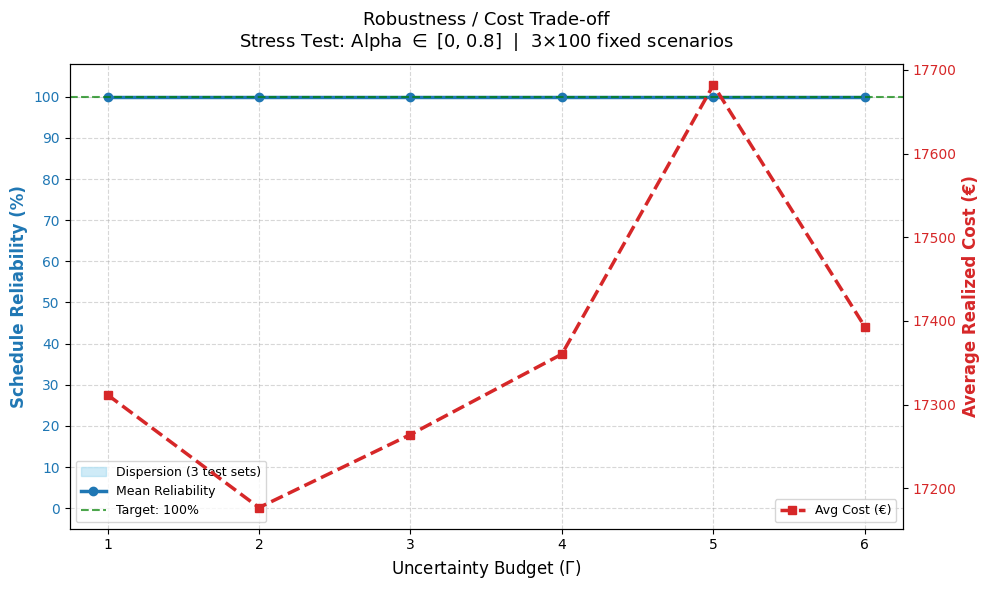

Chart saved: analyse_robustesse_alpha_0.8.png



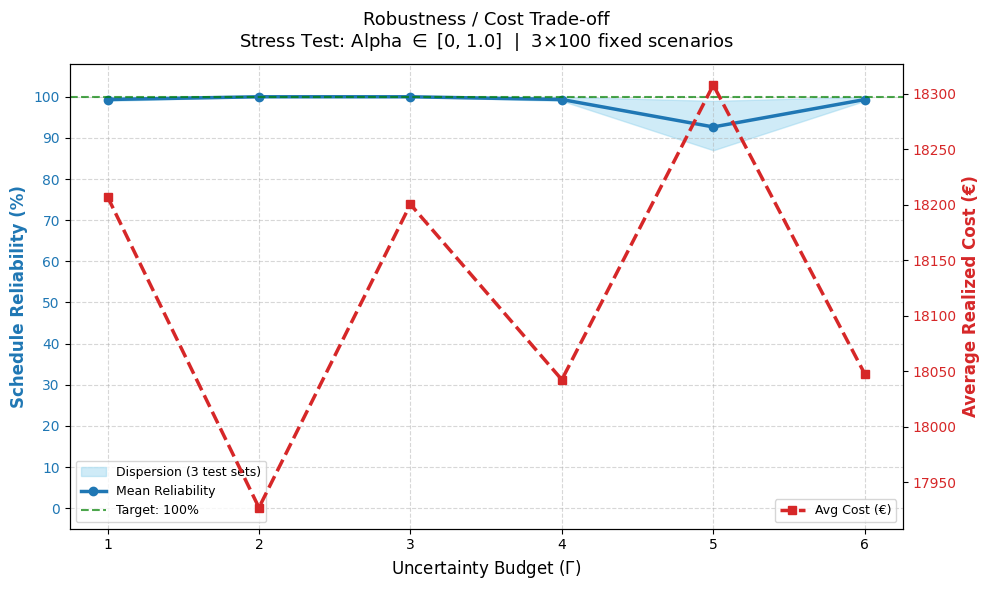

Chart saved: analyse_robustesse_alpha_1.0.png



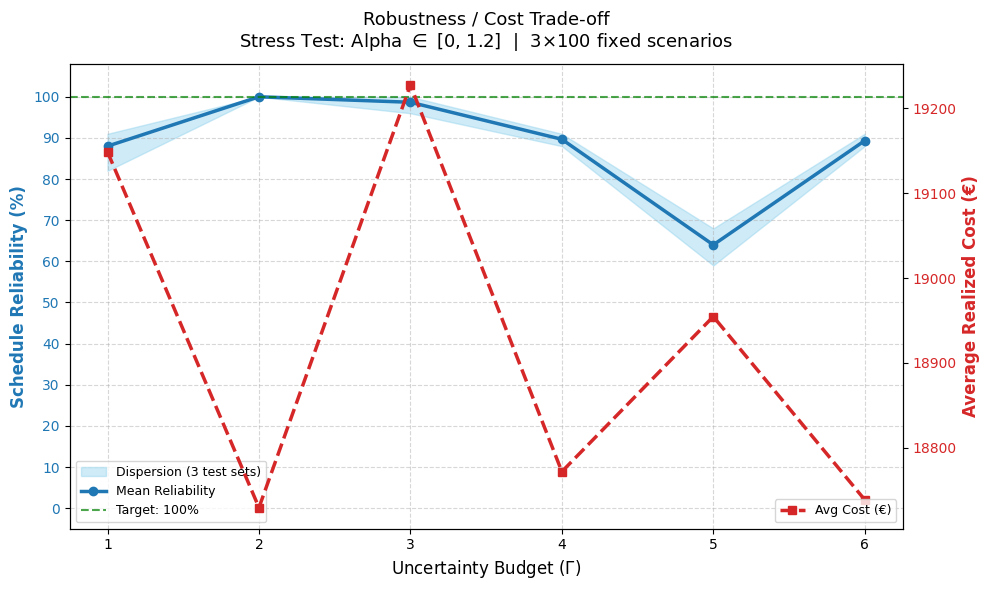

Chart saved: analyse_robustesse_alpha_1.2.png



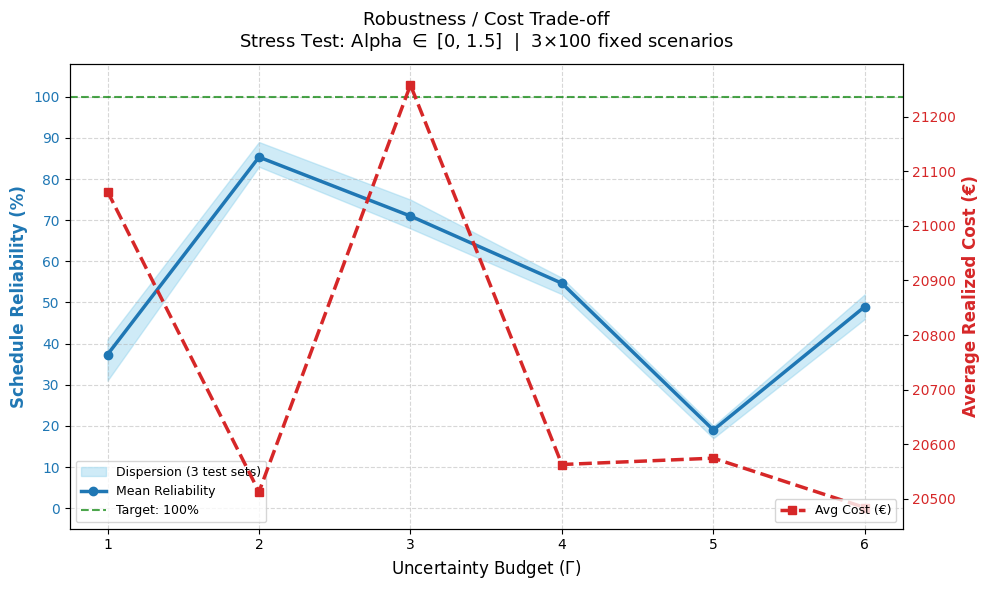

Chart saved: analyse_robustesse_alpha_1.5.png



In [9]:
for current_alpha, df_alpha in all_results.items():
    fig, ax1 = plt.subplots(figsize=(10, 6))

    gammas    = df_alpha['Gamma'].tolist()
    rel_mean  = df_alpha['Reliability_mean'].tolist()
    rel_min   = df_alpha['Reliability_min'].tolist()
    rel_max   = df_alpha['Reliability_max'].tolist()
    costs     = df_alpha['Avg_Cost'].tolist()

    # --- Left axis: Reliability ---
    color_rel = 'tab:blue'
    ax1.set_xlabel('Uncertainty Budget ($\\Gamma$)', fontsize=12)
    ax1.set_ylabel('Schedule Reliability (%)', color=color_rel, fontweight='bold', fontsize=12)

    # Dispersion band across test sets
    ax1.fill_between(
        gammas, rel_min, rel_max,
        color='skyblue', alpha=0.4,
        label=f'Dispersion ({N_TEST_SETS} test sets)'
    )
    ax1.plot(
        gammas, rel_mean,
        marker='o', color=color_rel, linewidth=2.5,
        label='Mean Reliability'
    )
    ax1.axhline(y=100, color='green', linestyle='--', alpha=0.7, label='Target: 100%')

    ax1.tick_params(axis='y', labelcolor=color_rel)
    ax1.set_ylim(-5, 108)
    ax1.set_yticks(range(0, 110, 10))
    ax1.set_xticks(gammas)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='lower left', fontsize=9)

    # --- Right axis: Average Cost ---
    ax2 = ax1.twinx()
    color_cost = 'tab:red'
    ax2.set_ylabel('Average Realized Cost (€)', color=color_cost, fontweight='bold', fontsize=12)
    ax2.plot(
        gammas, costs,
        marker='s', linestyle='--', color=color_cost, linewidth=2.5,
        label='Avg Cost (€)'
    )
    ax2.tick_params(axis='y', labelcolor=color_cost)
    ax2.legend(loc='lower right', fontsize=9)

    plt.title(
        f"Robustness / Cost Trade-off\n"
        f"Stress Test: Alpha $\\in$ [0, {current_alpha}]  |  "
        f"{N_TEST_SETS}×{N_SCENARIOS} fixed scenarios",
        fontsize=13, pad=12
    )
    fig.tight_layout()
    image_name = f"analyse_robustesse_alpha_{current_alpha}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, image_name), dpi=150)
    plt.show()
    print(f"Chart saved: analyse_robustesse_alpha_{current_alpha}.png\n")

## 8. Export: Detailed Planning per Gamma

For each solved $\Gamma$, we export an Excel file showing the patient schedule with the overtime amounts actually retained by the model.

**Key logic**: The robust model protects against the $\Gamma$ patients with the *highest* potential overtime on each day. These are the patients ranked by descending `t_sup`. The column `Overtime_Retained_In_Model` shows which patients' overtime is "activated" in the worst-case scenario.

In [10]:
print(">>> Exporting detailed planning per Gamma...")

for g, (x_sol, y_sol) in solutions_cache.items():
    rows = []
    for k in days:
        active_specialty = next(
            (j for j in specialties if y_sol[j][k].varValue > 0.5),
            None
        )
        if active_specialty is None:
            continue

        patients_today = [
            i for i in patients
            if x_sol[i][k].varValue > 0.5 and patient_specialty[i] == active_specialty
        ]

        # Rank patients by descending overtime potential → top Gamma are the "worst-case" ones
        ranked = sorted(patients_today, key=lambda i: t_sup[i], reverse=True)
        top_gamma_ids = set(ranked[:g])

        for i in patients_today:
            rows.append({
                "Gamma_Model":               g,
                "Day_Index":                 k,
                "Day_Name":                  day_map[k],
                "Specialty":                 active_specialty,
                "Patient_ID":                i,
                "Base_Duration_H":           t_fixe[i],
                "Overtime_Retained_In_Model": t_sup[i] if i in top_gamma_ids else 0.0,
                "Max_Potential_Overtime":    t_sup[i],
            })

    if rows:
        file_name = f"planning_robuste_gamma_{g}.xlsx"
        full_path = os.path.join(OUTPUT_DIR, file_name) # On ajoute le dossier
        pd.DataFrame(rows).to_excel(full_path, index=False)
        print(f"  Gamma={g}: exported {len(rows)} rows -> {full_path}")

print("\nDone.")

>>> Exporting detailed planning per Gamma...
  Gamma=1: exported 56 rows -> results_robust/planning_robuste_gamma_1.xlsx
  Gamma=2: exported 56 rows -> results_robust/planning_robuste_gamma_2.xlsx
  Gamma=3: exported 56 rows -> results_robust/planning_robuste_gamma_3.xlsx
  Gamma=4: exported 56 rows -> results_robust/planning_robuste_gamma_4.xlsx
  Gamma=5: exported 56 rows -> results_robust/planning_robuste_gamma_5.xlsx
  Gamma=6: exported 56 rows -> results_robust/planning_robuste_gamma_6.xlsx

Done.


***

## 9. Understanding the Cost-Reliability Paradox & The "Dense-Packing" Loophole

When analyzing the Pareto fronts across different severity levels ($\alpha \in [0.8, 1.0, 1.2, 1.5]$), we observe a counter-intuitive "yo-yo" effect in the cost curve. Theoretically, higher protection ($\Gamma$) should mean strictly higher costs. However, the charts show the cost dropping, spiking, and sometimes dropping again while reliability plummets. 

To understand this, we must distinguish between the **Theoretical Cost** (optimized by the solver) and the **Realized Cost** (actual cost after simulating 100 real-world scenarios).

### The Solver's Strategy vs. Real-World Reality
During optimization, the solver minimizes two factors: highly penalized weekend room openings, and the theoretical overtime (calculated only for the $\Gamma$ most at-risk patients, assuming others have zero delay).

* **The Sweet Spot ($\Gamma = 1$ or $2$):** The solver confidently groups patients during the week without triggering weekend costs. This level of protection absorbs normal delays, keeping realized costs low and reliability high.
* **The Cost Surge ($\Gamma = 3$):** Pushed to guarantee more protection, the solver runs out of weekday capacity and is forced to open a penalized weekend room. The baseline fixed cost explodes to maintain 100% safety.
* **The Mathematical Loophole ($\Gamma \ge 4$):** Instead of opening *more* weekend rooms, the solver resorts to a mathematical hack: **Dense-Packing**.

### Proof of the Exploit: The ORTHO Example
An in-depth analysis of the generated robust schedules (e.g., `planning_robuste_gamma_3.xlsx`) reveals exactly how the solver exploits the $\Gamma$ constraint. To minimize its objective cost, it aggressively sorts patients by risk:
* **Day 1 (The High-Risk Cluster):** The solver groups the 8 most risky ORTHO patients together. It pays the theoretical overtime for the top 3 worst cases, but manages to "hide" the remaining 5 highly risky patients under the $\Gamma$ shield, effectively ignoring nearly 2 hours of severe potential delay.
* **Day 3 (The Low-Risk Cluster):** It groups the remaining 9 low-risk patients. Because their overtime potential is tiny, the top 3 penalties cost the solver almost nothing.

**The Reality Clash:** By mathematically saving money on paper, the solver creates a ticking time bomb. In the simulation, when the severity factor ($\alpha$) applies delays to *all* patients, the "hidden" risks materialize. The room instantly breaches the absolute 10-hour physical limit, causing reliability to collapse.

---

## 10. Executive Conclusion & Strategic Recommendations

While the stochastic model focuses on minimizing the *average* cost, the robust optimization model acts as an insurance policy. By understanding the dense-packing exploit, we can formulate clear managerial recommendations:

### Strategic Summary Matrix

| Uncertainty Budget ($\Gamma$) | Operational Interpretation | Strategic Recommendation |
| :---: | :--- | :--- |
| **$\Gamma = 1$** | Protects against 1 maximum delay per day. | **Insufficient.** Too fragile for real-world hospital delays. |
| **$\Gamma = 2$** | Protects against 2 simultaneous worst-cases. | **Optimal.** Best balance of near 100% reliability and lowest cost for standard operations ($\alpha \le 1.0$). |
| **$\Gamma = 3$** | Protects against 3 simultaneous worst-cases. | **Reserved for Extreme Stress.** Necessary only if severe delays ($\alpha \ge 1.5$) are expected. |
| **$\Gamma \ge 4$** | Over-conservative protection. | **Avoid.** Triggers the dense-packing loophole, creating fragmented and operationally brittle schedules. |

---

## 11. Future Perspectives: Towards a Hybrid Stochastic-Robust Model

While our robust model successfully guarantees feasibility under normal conditions, the drop in reliability at higher $\Gamma$ values highlights a structural limit of the classic Bertsimas & Sim approach: it assumes patients not covered by the uncertainty budget will experience **zero delay**. 

However, under a uniform probability distribution, the expected delay for any patient is strictly positive: $\mathbb{E}[\text{delay}] = \frac{\alpha}{2} \times t_{sup}$. Because the robust solver is "blind" to this expected average delay, it tends to over-pack low-risk patients into a single room.

**Proposed Improvement: "Light Robustness"**
To achieve a truly optimal schedule, future iterations should adopt a **Hybrid Stochastic-Robust approach**. Instead of using the absolute best-case duration ($t_{fixed}$) as the baseline, the model should use the expected duration:
$$t_{base\_adjusted} = t_{fixed} + \left(\frac{\alpha}{2} \times t_{sup}\right)$$

The uncertainty budget $\Gamma$ would then solely be used to protect the schedule against the *variance* (the extreme tail-ends of the distribution). This forces the solver to acknowledge the statistical weight of every patient, permanently closing the "dense-packing" loophole and producing a schedule mathematically resilient to both average accumulations and extreme worst-case scenarios.

***
